# F1 Performance Explorer — temporada 2019

**Pregunta central:** ¿Qué pilotos y escuderías rindieron mejor durante la temporada, y cuáles consiguieron resultados superiores o inferiores a su posición de largada?

## Etapa 1 — carga y comprensión

En esta etapa no limpio ni uno tablas. Primero compruebo que los archivos carguen y reviso qué representa una fila y cuál es la clave de cada tabla.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEASON = 2019

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

assert DATA_RAW.exists(), f"No se encontró la carpeta de datos: {DATA_RAW}"
print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Temporada elegida: {SEASON}")

Raíz del proyecto: D:\Proyectos\f1-performance-explorer
Temporada elegida: 2019


In [2]:
races = pd.read_csv(DATA_RAW / "races.csv")
results = pd.read_csv(DATA_RAW / "results.csv")
drivers = pd.read_csv(DATA_RAW / "drivers.csv")
constructors = pd.read_csv(DATA_RAW / "constructors.csv")
circuits = pd.read_csv(DATA_RAW / "circuits.csv")
status = pd.read_csv(DATA_RAW / "status.csv")

tables = {
    "races": races,
    "results": results,
    "drivers": drivers,
    "constructors": constructors,
    "circuits": circuits,
    "status": status,
}

pd.DataFrame(
    {"filas": {name: len(df) for name, df in tables.items()},
     "columnas": {name: df.shape[1] for name, df in tables.items()}}
).rename_axis("tabla")

,filas,columnas
tabla,,
races,1172,18
results,27524,18
drivers,865,9
constructors,214,5
circuits,78,9
status,141,2


In [3]:
races["raceId"].is_unique

results.duplicated(subset=["raceId", "driverId"]).sum()

results.eq("\\N").sum().sort_values(ascending=False)


time               19368
milliseconds       19368
fastestLapSpeed    19272
fastestLap         18563
fastestLapTime     18563
rank               18305
position           10953
grid                  42
number                 6
resultId               0
raceId                 0
points                 0
positionText           0
driverId               0
constructorId          0
positionOrder          0
laps                   0
statusId               0
dtype: int64

In [4]:
race_ids_2019 = races.loc[races["year"] == 2019, "raceId"]

results_2019 = results.loc[
    results["raceId"].isin(race_ids_2019)
    ].copy()

results_2019.eq("\\N").sum().sort_values(ascending=False)

time               224
milliseconds       224
position            50
fastestLapSpeed      4
fastestLapTime       4
fastestLap           4
raceId               0
resultId             0
number               0
driverId             0
points               0
positionOrder        0
positionText         0
grid                 0
constructorId        0
laps                 0
rank                 0
statusId             0
dtype: int64

In [5]:
columns_to_inspect = [
    "raceId",
    "driverId",
    "grid",
    "position",
    "positionOrder",
    "laps",
    "statusId",
]

results_2019.loc[
    results_2019["position"] == "\\N",
    columns_to_inspect
    ].head(10)

,raceId,driverId,grid,position,positionOrder,laps,statusId
24214,1010,154,6,\N,18,29,36
24215,1010,817,12,\N,19,28,137
24216,1010,832,18,\N,20,9,5
24233,1011,807,17,\N,17,53,5
24234,1011,817,10,\N,18,53,60
24235,1011,832,7,\N,19,53,130
24236,1011,154,11,\N,20,16,31
24255,1012,826,11,\N,19,41,4
24256,1012,807,8,\N,20,16,131
24273,1013,842,0,\N,17,38,7


In [6]:
status_ids_without_position = results_2019.loc[
    results_2019["position"] == "\\N",
    "statusId"
    ].unique()

status.loc[

status["statusId"].isin(status_ids_without_position)
    ]

,statusId,status
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine
6,7,Transmission
8,9,Hydraulics
19,20,Spun off
21,22,Suspension
22,23,Brakes
24,25,Overheating


- La fila "results" representa el resultado de un piloto particular en una carrera particular.
- La columna "grid" representa la posicion desde la que largó el piloto.
- La columna "position" representa la posicion final numerica cuando esta disponible. \N significa que ese dato no esta disponible.
- La columna "positionOrder" es el orden completo de los participantes en el resultado,  incluyendo pilotos sin "position".
- La columna "statusId" explica como termino la participacion.

In [7]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [8]:
races.shape

(1172, 18)

In [9]:
races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1172 non-null   int64 
 1   year         1172 non-null   int64 
 2   round        1172 non-null   int64 
 3   circuitId    1172 non-null   int64 
 4   name         1172 non-null   object
 5   date         1172 non-null   object
 6   time         1172 non-null   object
 7   url          1172 non-null   object
 8   fp1_date     1172 non-null   object
 9   fp1_time     1172 non-null   object
 10  fp2_date     1172 non-null   object
 11  fp2_time     1172 non-null   object
 12  fp3_date     1172 non-null   object
 13  fp3_time     1172 non-null   object
 14  quali_date   1172 non-null   object
 15  quali_time   1172 non-null   object
 16  sprint_date  1172 non-null   object
 17  sprint_time  1172 non-null   object
dtypes: int64(4), object(14)
memory usage: 164.9+ KB


In [10]:
races.isna().sum()

raceId         0
year           0
round          0
circuitId      0
name           0
date           0
time           0
url            0
fp1_date       0
fp1_time       0
fp2_date       0
fp2_time       0
fp3_date       0
fp3_time       0
quali_date     0
quali_time     0
sprint_date    0
sprint_time    0
dtype: int64

In [11]:
races.duplicated().sum()

np.int64(0)

In [12]:
races_2019 = races.loc[
    races["year"] == 2019
    ].sort_values("round").copy()

races_2019



,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
997,1010,2019,1,1,Australian Grand Prix,2019-03-17,05:10:00,http://en.wikipedia.org/wiki/2019_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
998,1011,2019,2,3,Bahrain Grand Prix,2019-03-31,15:10:00,http://en.wikipedia.org/wiki/2019_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
999,1012,2019,3,17,Chinese Grand Prix,2019-04-14,06:10:00,http://en.wikipedia.org/wiki/2019_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1000,1013,2019,4,73,Azerbaijan Grand Prix,2019-04-28,12:10:00,http://en.wikipedia.org/wiki/2019_Azerbaijan_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1001,1014,2019,5,4,Spanish Grand Prix,2019-05-12,13:10:00,http://en.wikipedia.org/wiki/2019_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1002,1015,2019,6,6,Monaco Grand Prix,2019-05-26,13:10:00,http://en.wikipedia.org/wiki/2019_Monaco_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1003,1016,2019,7,7,Canadian Grand Prix,2019-06-09,18:10:00,http://en.wikipedia.org/wiki/2019_Canadian_Gra...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1004,1017,2019,8,34,French Grand Prix,2019-06-23,13:10:00,http://en.wikipedia.org/wiki/2019_French_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1005,1018,2019,9,70,Austrian Grand Prix,2019-06-30,13:10:00,http://en.wikipedia.org/wiki/2019_Austrian_Gra...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1006,1019,2019,10,9,British Grand Prix,2019-07-14,13:10:00,http://en.wikipedia.org/wiki/2019_British_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [13]:
races_2019.eq("\\N").sum().sort_values(ascending=False)

fp1_time       21
fp1_date       21
sprint_date    21
sprint_time    21
quali_time     21
quali_date     21
fp3_time       21
fp3_date       21
fp2_time       21
fp2_date       21
year            0
raceId          0
time            0
url             0
circuitId       0
round           0
name            0
date            0
dtype: int64

In [14]:
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [15]:
drivers.shape

(865, 9)

In [16]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     865 non-null    int64 
 1   driverRef    865 non-null    object
 2   number       865 non-null    object
 3   code         865 non-null    object
 4   forename     865 non-null    object
 5   surname      865 non-null    object
 6   dob          865 non-null    object
 7   nationality  865 non-null    object
 8   url          865 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.9+ KB


In [17]:
print("Filas duplicadas:", drivers.duplicated().sum())
print("¿driverId es único?:", drivers["driverId"].is_unique)

drivers.eq("\\N").sum().sort_values(ascending=False)

Filas duplicadas: 0
¿driverId es único?: True


number         802
code           757
driverId         0
driverRef        0
forename         0
surname          0
dob              0
nationality      0
url              0
dtype: int64

In [18]:
constructors.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [19]:
constructors.shape

(214, 5)

In [20]:
constructors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   214 non-null    int64 
 1   constructorRef  214 non-null    object
 2   name            214 non-null    object
 3   nationality     214 non-null    object
 4   url             214 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.5+ KB


In [21]:
print("Cantidad de filas duplicadas:", constructors.duplicated().sum())
print("¿constructorId es unico?", constructors["constructorId"].is_unique)

constructors.eq("\\N").sum().sort_values(ascending=False)

Cantidad de filas duplicadas: 0
¿constructorId es unico? True


constructorId     0
constructorRef    0
name              0
nationality       0
url               0
dtype: int64

In [22]:
circuits.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [23]:
circuits.shape

(78, 9)

In [24]:
circuits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   78 non-null     int64  
 1   circuitRef  78 non-null     object 
 2   name        78 non-null     object 
 3   location    78 non-null     object 
 4   country     78 non-null     object 
 5   lat         78 non-null     float64
 6   lng         78 non-null     float64
 7   alt         78 non-null     int64  
 8   url         78 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.6+ KB


In [25]:
print("Cantidad de duplicados:", circuits.duplicated().sum())
print("circuitId es unico?", circuits["circuitId"].is_unique)

circuits.eq("\\N").sum().sort_values(ascending=False)

Cantidad de duplicados: 0
circuitId es unico? True


circuitId     0
circuitRef    0
name          0
location      0
country       0
lat           0
lng           0
alt           0
url           0
dtype: int64

In [26]:
status.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [27]:
status.shape

(141, 2)

In [28]:
status.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   statusId  141 non-null    int64 
 1   status    141 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.3+ KB


In [29]:
print("Cantidad de duplicados:", status.duplicated().sum())
print("statusId es unico?:", status["statusId"].is_unique)

status.eq("\\N").sum().sort_values(ascending=False)


Cantidad de duplicados: 0
statusId es unico?: True


statusId    0
status      0
dtype: int64

| Tabla | ¿Qué representa una fila? | Clave primaria | Conexiones importantes |
|---|---|---|---|
| races | Cada fila representa una carrera | raceId |  circuits y results |
| results | Cada fila representa el resultado de un piloto en las carreras | resultId |  drivers/races/constructors/status |
| drivers | Cada fila representa un piloto | driverId | results |
| constructors | Cada fila representa un equipo | constructorId | results |
| circuits | Cada fila representa un circuito | circuitId | races |
| status | cada fila representa un posible estado final de los pilotos | statusId | results |

## Etapa 2 — Limpieza y selección de 2019

Trabajo sobre copias para conservar los datos originales y poder reconstruir el análisis si necesito corregir algún paso. El texto \N representa datos faltantes; lo reemplazo por pd.NA para que Pandas los reconozca como tales. Elegí la temporada 2019 porque no tuvo carreras sprint, lo que permite analizar los puntos del campeonato utilizando únicamente los resultados de los Grandes Premios.

In [30]:
races_clean = races.copy().replace("\\N", pd.NA)
results_clean = results.copy().replace("\\N", pd.NA)

In [31]:
print(
    "Original - textos \\N:",
    results["position"].eq("\\N").sum()
)

print(
    "Original - faltantes reconocidos:",
    results["position"].isna().sum()
)

print(
    "Copia limpia - textos \\N:",
    results_clean["position"].eq("\\N").sum()
)

print(
    "Copia limpia - faltantes reconocidos:",
    results_clean["position"].isna().sum()
)

print(
    "¿Se conservó la cantidad de filas?",
    len(results_clean) == len(results)
)

Original - textos \N: 10953
Original - faltantes reconocidos: 0
Copia limpia - textos \N: 0
Copia limpia - faltantes reconocidos: 10953
¿Se conservó la cantidad de filas? True


In [32]:
races_2019 = races_clean.loc[
    races_clean["year"].eq(SEASON)
].copy()

results_2019 = results_clean.loc[
    results_clean["raceId"].isin(races_2019["raceId"])
].copy()

In [33]:
print("Carreras de 2019:", len(races_2019))
print("Resultados de 2019:", len(results_2019))
print(
    "Posiciones faltantes reconocidas:",
    results_2019["position"].isna().sum()
)

Carreras de 2019: 21
Resultados de 2019: 420
Posiciones faltantes reconocidas: 50


In [34]:
print("Tipo anterior:", races_2019["date"].dtype)

races_2019["date"] = pd.to_datetime(
    races_2019["date"],
    format="%Y-%m-%d",
    errors="raise"
)

print("Tipo nuevo:", races_2019["date"].dtype)
print("Primera carrera:", races_2019["date"].min())
print("Ultima carrera:", races_2019["date"].max())

Tipo anterior: object
Tipo nuevo: datetime64[ns]
Primera carrera: 2019-03-17 00:00:00
Ultima carrera: 2019-12-01 00:00:00


In [35]:
assert races_2019["date"].dt.year.eq(SEASON).all()


In [36]:
results_2019[
    ["grid", "position", "positionOrder", "points", "laps"]
    ].dtypes

grid              object
position          object
positionOrder      int64
points           float64
laps               int64
dtype: object

In [37]:
results_2019["grid"] = (
    pd.to_numeric(results_2019["grid"], errors="raise")
    .astype("Int64")
)

results_2019["position"] = (
    pd.to_numeric(results_2019["position"], errors="raise")
    .astype("Int64")
)

In [38]:
print(
    results_2019[
        ["grid", "position", "positionOrder", "points", "laps"]
        ].dtypes
)

print(
    "Faltantes en position:",
    results_2019["position"].isna().sum()
)

grid               Int64
position           Int64
positionOrder      int64
points           float64
laps               int64
dtype: object
Faltantes en position: 50


In [39]:
assert races_2019["raceId"].is_unique

assert results_2019["resultId"].is_unique

assert not results_2019.duplicated(
    subset=["raceId", "driverId"]
).any()

assert results_2019["raceId"].isin(
    races_2019["raceId"]
).all()

print("Todas las validaciones de claves fueron superadas.")


Todas las validaciones de claves fueron superadas.


## Etapa 3 — Unión de las tablas

Uno los resultados con las tablas de pilotos, constructores, carreras, circuitos y estados finales para reunir la información necesaria para el análisis. Cada fila representa el resultado de un piloto en un Gran Premio de la temporada 2019. Compruebo que las uniones conserven la cantidad de filas para detectar posibles pérdidas o multiplicaciones accidentales de registros. También verifico que cada resultado encuentre su información correspondiente en las otras tablas.

In [40]:
race_lookup = (
    races_2019[
        ["raceId", "year", "round", "date", "name", "circuitId"]
        ]
    .rename(
        columns={
            "year": "season",
            "name": "race_name",
        }
    )
)

In [41]:
analysis = results_2019.merge(
    race_lookup,
    on="raceId",
    how="left",
    validate="many_to_one",
    indicator="race_match",
)


In [42]:
print("Filas antes:", len(results_2019))
print("Filas despues:", len(analysis))
print(analysis["race_match"].value_counts())

assert len(analysis) == len(results_2019)
assert analysis["race_match"].eq("both").all()

print("Union validada")

Filas antes: 420
Filas despues: 420
race_match
both          420
left_only       0
right_only      0
Name: count, dtype: int64
Union validada


In [43]:
driver_lookup = drivers[
    ["driverId", "forename", "surname"]
    ].copy()

driver_lookup["driver"] = (
    driver_lookup["forename"].str.strip()
    + " "
    + driver_lookup["surname"].str.strip()
)

driver_lookup = driver_lookup[
    ["driverId", "driver"]
    ]

driver_lookup.head()

,driverId,driver
0,1,Lewis Hamilton
1,2,Nick Heidfeld
2,3,Nico Rosberg
3,4,Fernando Alonso
4,5,Heikki Kovalainen


In [44]:
analysis = analysis.merge(
    driver_lookup,
    on="driverId",
    how="left",
    validate="many_to_one",
    indicator="driver_match",
)

In [45]:
print("Cantidad de filas:", len(analysis))
print(analysis["driver_match"].value_counts())

assert len(analysis) == 420
assert analysis["driver_match"].eq("both").all()
assert analysis["driver"].notna().all()

analysis[
    ["race_name", "driverId", "driver"]
].head()

Cantidad de filas: 420
driver_match
both          420
left_only       0
right_only      0
Name: count, dtype: int64


,race_name,driverId,driver
0,Australian Grand Prix,822,Valtteri Bottas
1,Australian Grand Prix,1,Lewis Hamilton
2,Australian Grand Prix,830,Max Verstappen
3,Australian Grand Prix,20,Sebastian Vettel
4,Australian Grand Prix,844,Charles Leclerc


In [46]:
constructor_lookup = (
    constructors[
        ["constructorId", "name"]
        ]
        .rename(columns={"name": "constructor"})
)

constructor_lookup.head()

,constructorId,constructor
0,1,McLaren
1,2,BMW Sauber
2,3,Williams
3,4,Renault
4,5,Toro Rosso


In [47]:
analysis = analysis.merge(
    constructor_lookup,
    on="constructorId",
    how="left",
    validate="many_to_one",
    indicator="constructor_match",
)



In [48]:
print("Cantidad de filas:", len(analysis))
print(analysis["constructor_match"].value_counts())

assert len(analysis) == 420
assert analysis["constructor_match"].eq("both").all()
assert analysis["constructor"].notna().all()

print("Unión de constructores validada.")

Cantidad de filas: 420
constructor_match
both          420
left_only       0
right_only      0
Name: count, dtype: int64
Unión de constructores validada.


In [49]:
circuit_lookup = (
    circuits[
        ["circuitId", "name"]
        ]
        .rename(columns={"name": "circuit"})
)

circuit_lookup.head()

,circuitId,circuit
0,1,Albert Park Grand Prix Circuit
1,2,Sepang International Circuit
2,3,Bahrain International Circuit
3,4,Circuit de Barcelona-Catalunya
4,5,Istanbul Park


In [50]:
analysis = analysis.merge(
    circuit_lookup,
    on="circuitId",
    how="left",
    validate="many_to_one",
    indicator="circuit_match",
)

In [51]:
print("Cantidad de filas:", len(analysis))
print(analysis["circuit_match"].value_counts())

assert len(analysis) == 420
assert analysis["circuit_match"].eq("both").all()
assert analysis["circuit"].notna().all()

print("Union de circuitos validada")

Cantidad de filas: 420
circuit_match
both          420
left_only       0
right_only      0
Name: count, dtype: int64
Union de circuitos validada


In [52]:
status_lookup = (
    status[
        ["statusId", "status"]
        ]
)

status_lookup.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [53]:
analysis = analysis.merge(
    status_lookup,
    on="statusId",
    how="left",
    validate="many_to_one",
    indicator="status_match",
)



In [54]:
print("Cantidad de filas:", len(analysis))
print(analysis["status_match"].value_counts())

assert len(analysis) == 420
assert analysis["status_match"].eq("both").all()
assert analysis["status"].notna().all()

print("Union de status validada")

Cantidad de filas: 420
status_match
both          420
left_only       0
right_only      0
Name: count, dtype: int64
Union de status validada


In [55]:
match_columns = [
    "race_match",
    "driver_match",
    "constructor_match",
    "circuit_match",
    "status_match"
]

analysis_clean = (
    analysis
    .drop(columns=match_columns)
    .rename(columns={"position": "finish_position"})
    .sort_values(["round", "positionOrder"])
    .reset_index(drop=True)
)

In [56]:
analysis_columns = [
    "resultId",
    "raceId",
    "driverId",
    "constructorId",
    "circuitId",
    "statusId",
    "season",
    "round",
    "date",
    "race_name",
    "circuit",
    "driver",
    "constructor",
    "grid",
    "finish_position",
    "positionText",
    "positionOrder",
    "points",
    "laps",
    "status",
]

analysis_clean = analysis_clean[analysis_columns]
    

In [57]:
print("Forma final:", analysis_clean.shape)
print("Faltantes en finish_position:", analysis_clean["finish_position"].isna().sum())

analysis_clean.head(10)

Forma final: (420, 20)
Faltantes en finish_position: 50


,resultId,raceId,driverId,constructorId,circuitId,statusId,season,round,date,race_name,circuit,driver,constructor,grid,finish_position,positionText,positionOrder,points,laps,status
0,24203,1010,822,131,1,1,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Valtteri Bottas,Mercedes,2,1,1,1,26.0,58,Finished
1,24204,1010,1,131,1,1,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,1,2,2,2,18.0,58,Finished
2,24205,1010,830,9,1,1,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Max Verstappen,Red Bull,4,3,3,3,15.0,58,Finished
3,24206,1010,20,6,1,1,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,3,4,4,4,12.0,58,Finished
4,24207,1010,844,6,1,1,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Charles Leclerc,Ferrari,5,5,5,5,10.0,58,Finished
5,24208,1010,825,210,1,1,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Kevin Magnussen,Haas F1 Team,7,6,6,6,8.0,58,Finished
6,24209,1010,807,4,1,11,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Nico Hülkenberg,Renault,11,7,7,7,6.0,57,+1 Lap
7,24210,1010,8,51,1,11,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Kimi Räikkönen,Alfa Romeo,9,8,8,8,4.0,57,+1 Lap
8,24211,1010,840,211,1,11,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Lance Stroll,Racing Point,16,9,9,9,2.0,57,+1 Lap
9,24212,1010,826,5,1,11,2019,1,2019-03-17,Australian Grand Prix,Albert Park Grand Prix Circuit,Daniil Kvyat,Toro Rosso,15,10,10,10,1.0,57,+1 Lap


In [58]:
analysis_clean.loc[
    analysis_clean["finish_position"].isna(), "status"
    ].value_counts()

status
Collision           12
Brakes               5
Accident             4
Engine               4
Power loss           3
Suspension           2
Spun off             2
Collision damage     2
Wheel                2
Disqualified         2
Power Unit           2
Out of fuel          1
Damage               1
Retired              1
Transmission         1
Water pressure       1
Exhaust              1
Hydraulics           1
Overheating          1
Withdrew             1
Oil leak             1
Name: count, dtype: int64

In [59]:
analysis_clean.loc[
    analysis_clean["grid"].eq(0),
    [
        "round",
        "race_name",
        "driver",
        "grid",
        "finish_position",
        "positionOrder",
        "status",
    ],
    ]

,round,race_name,driver,grid,finish_position,positionOrder,status
49,3,Chinese Grand Prix,Alexander Albon,0,10,10,+1 Lap
69,4,Azerbaijan Grand Prix,Kimi Räikkönen,0,10,10,+1 Lap
75,4,Azerbaijan Grand Prix,Robert Kubica,0,16,16,+2 Laps
76,4,Azerbaijan Grand Prix,Pierre Gasly,0,<NA>,17,Transmission
92,5,Spanish Grand Prix,Nico Hülkenberg,0,13,13,Finished
136,7,Canadian Grand Prix,Kevin Magnussen,0,17,17,+2 Laps
177,9,Austrian Grand Prix,George Russell,0,18,18,+2 Laps
256,13,Belgian Grand Prix,Robert Kubica,0,17,17,+1 Lap
274,14,Italian Grand Prix,Kimi Räikkönen,0,15,15,+1 Lap
304,16,Russian Grand Prix,Alexander Albon,0,5,5,Finished


## Etapa 4 — Definición de métricas

Calculo las posiciones ganadas restando la posición final a la posición de largada. Un valor positivo indica una ganancia neta de posiciones; uno negativo, una pérdida neta; y cero indica que el piloto terminó en la misma posición desde la que largó. Esta métrica no representa la cantidad de adelantamientos en pista, porque las posiciones también pueden cambiar por abandonos de otros pilotos, estrategias o sanciones. Además, un piloto puede ganar y perder posiciones durante la carrera sin que esos movimientos queden reflejados individualmente en el resultado.

In [60]:
valid_position_comparison = (
    analysis_clean["grid"].gt(0) & analysis_clean["finish_position"].notna()
)

analysis_clean["position_gained"] = (
    analysis_clean["grid"] - analysis_clean["finish_position"]
).where(valid_position_comparison, pd.NA).astype("Int64")

In [61]:
print("Comparaciones válidas:", valid_position_comparison.sum())
print(
    "Posiciones ganadas sin calcular:",
    analysis_clean["position_gained"].isna().sum()
)

analysis_clean[
    [
        "round",
        "race_name",
        "driver",
        "grid",
        "finish_position",
        "position_gained",
        "status",
    ]
].head(15)

Comparaciones válidas: 359
Posiciones ganadas sin calcular: 61


,round,race_name,driver,grid,finish_position,position_gained,status
0,1,Australian Grand Prix,Valtteri Bottas,2,1,1,Finished
1,1,Australian Grand Prix,Lewis Hamilton,1,2,-1,Finished
2,1,Australian Grand Prix,Max Verstappen,4,3,1,Finished
3,1,Australian Grand Prix,Sebastian Vettel,3,4,-1,Finished
4,1,Australian Grand Prix,Charles Leclerc,5,5,0,Finished
5,1,Australian Grand Prix,Kevin Magnussen,7,6,1,Finished
6,1,Australian Grand Prix,Nico Hülkenberg,11,7,4,+1 Lap
7,1,Australian Grand Prix,Kimi Räikkönen,9,8,1,+1 Lap
8,1,Australian Grand Prix,Lance Stroll,16,9,7,+1 Lap
9,1,Australian Grand Prix,Daniil Kvyat,15,10,5,+1 Lap


No calculo las posiciones ganadas cuando `grid = 0` o falta la posición final, porque no dispongo de una comparación válida entre largada y llegada.

In [62]:
analysis_clean["position_change_category"] = np.select(
    [
        analysis_clean["position_gained"].gt(0).fillna(False).to_numpy(dtype=bool),
        analysis_clean["position_gained"].lt(0).fillna(False).to_numpy(dtype=bool),
        analysis_clean["position_gained"].eq(0).fillna(False).to_numpy(dtype=bool),
    ],
    [
        "Ganó posiciones",
        "Perdió posiciones",
        "Sin cambio",
    ],
    default="No comparable",
)

analysis_clean["position_change_category"].value_counts()

position_change_category
Ganó posiciones      184
Perdió posiciones    115
No comparable         61
Sin cambio            60
Name: count, dtype: int64

## Etapa 5 — Análisis y visualización

Agrupo los resultados por piloto y constructor para resumir su desempeño durante la temporada, y por carrera para comparar los Grandes Premios e identificar casos destacados. Uso los puntos, la recuperación promedio de posiciones y el porcentaje de llegadas clasificadas para analizar distintas dimensiones del rendimiento. Estas métricas se complementan: sumar puntos, recuperar posiciones y obtener una llegada clasificada describen aspectos diferentes del desempeño. Los gráficos facilitan la comparación al mostrar diferencias entre los resultados y hacer visibles patrones o casos que podrían pasar desapercibidos en las tablas.

In [63]:
driver_position_summary = (
    analysis_clean
    .dropna(subset=["position_gained"])
    .groupby("driver", as_index=False)
    .agg(
        carreras_comparables=("position_gained", "count"),
        promedio_posiciones_ganadas=("position_gained", "mean"),
        total_posiciones_ganadas=("position_gained", "sum"),
        mejor_cambio=("position_gained", "max"),
        peor_cambio=("position_gained", "min"),
    )
    .sort_values(
        "promedio_posiciones_ganadas",
        ascending=False,
    )
)

driver_position_summary.head(10)

,driver,carreras_comparables,promedio_posiciones_ganadas,total_posiciones_ganadas,mejor_cambio,peor_cambio
9,Lance Stroll,19,3.368421,64,11,-3
5,Daniil Kvyat,18,3.333333,60,12,-2
18,Sergio Pérez,18,3.111111,56,11,-3
6,George Russell,18,2.222222,40,6,-1
2,Carlos Sainz,17,2.117647,36,17,-6
15,Robert Kubica,16,1.625,26,8,-3
12,Max Verstappen,19,1.157895,22,11,-2
0,Alexander Albon,18,1.055556,19,12,-9
19,Valtteri Bottas,19,1.052632,20,16,-6
8,Kimi Räikkönen,17,0.764706,13,6,-10


In [64]:
driver_start_finish_summary = (
    analysis_clean
    .dropna(subset=["position_gained"])
    .groupby("driver", as_index=False)
    .agg(
        carreras_comparables=("position_gained", "count"),
        grid_promedio=("grid", "mean"),
        llegada_promedio=("finish_position", "mean"),
        promedio_posiciones_ganadas=("position_gained", "mean"),
    )
    .sort_values("promedio_posiciones_ganadas", ascending=False)
)

driver_start_finish_summary.head(20)

,driver,carreras_comparables,grid_promedio,llegada_promedio,promedio_posiciones_ganadas
9,Lance Stroll,19,15.421053,12.052632,3.368421
5,Daniil Kvyat,18,14.0,10.666667,3.333333
18,Sergio Pérez,18,13.0,9.888889,3.111111
6,George Russell,18,17.611111,15.388889,2.222222
2,Carlos Sainz,17,9.941176,7.823529,2.117647
15,Robert Kubica,16,18.625,17.0,1.625
12,Max Verstappen,19,4.684211,3.526316,1.157895
0,Alexander Albon,18,10.055556,9.0,1.055556
19,Valtteri Bottas,19,3.736842,2.684211,1.052632
8,Kimi Räikkönen,17,11.470588,10.705882,0.764706


In [65]:
driver_performance_summary = (
    analysis_clean
    .groupby("driver", as_index=False)
    .agg(
        carreras=("resultId", "count"),
        llegadas_clasificadas=("finish_position", "count"),
        llegada_promedio=("finish_position", "mean"),
        puntos_totales=("points", "sum"),
        mejor_llegada=("finish_position", "min"),
    )
    .sort_values(
        ["llegada_promedio", "puntos_totales"],
        ascending=[True, False],
    )
)

driver_performance_summary.head(20)

,driver,carreras,llegadas_clasificadas,llegada_promedio,puntos_totales,mejor_llegada
11,Lewis Hamilton,21,21,2.380952,413.0,1
19,Valtteri Bottas,21,19,2.684211,326.0,1
12,Max Verstappen,21,19,3.526316,278.0,1
3,Charles Leclerc,21,19,4.210526,264.0,1
17,Sebastian Vettel,21,19,5.105263,240.0,1
2,Carlos Sainz,21,17,7.823529,96.0,3
0,Alexander Albon,21,20,8.85,92.0,4
14,Pierre Gasly,21,20,8.95,95.0,2
4,Daniel Ricciardo,21,15,9.4,54.0,4
10,Lando Norris,21,17,9.411765,49.0,6


In [66]:
driver_performance_summary["porcentaje_llegadas_clasificadas"] = (
    driver_performance_summary["llegadas_clasificadas"] / driver_performance_summary["carreras"] * 100
).round(1)

driver_performance_summary[
    [
        "driver",
        "carreras",
        "llegadas_clasificadas",
        "porcentaje_llegadas_clasificadas",
        "llegada_promedio",
        "puntos_totales",
    ]
].sort_values(
    "porcentaje_llegadas_clasificadas",
    ascending=False,
).head(10)

,driver,carreras,llegadas_clasificadas,porcentaje_llegadas_clasificadas,llegada_promedio,puntos_totales
11,Lewis Hamilton,21,21,100.0,2.380952,413.0
1,Antonio Giovinazzi,21,20,95.2,13.65,14.0
0,Alexander Albon,21,20,95.2,8.85,92.0
14,Pierre Gasly,21,20,95.2,8.95,95.0
3,Charles Leclerc,21,19,90.5,4.210526,264.0
12,Max Verstappen,21,19,90.5,3.526316,278.0
19,Valtteri Bottas,21,19,90.5,2.684211,326.0
17,Sebastian Vettel,21,19,90.5,5.105263,240.0
9,Lance Stroll,21,19,90.5,12.052632,21.0
7,Kevin Magnussen,21,19,90.5,13.210526,20.0


In [67]:
constructor_performance_summary = (
    analysis_clean
    .groupby("constructor", as_index=False)
    .agg(
        resultados=("resultId", "count"),
        llegadas_clasificadas=("finish_position", "count"),
        llegada_promedio=("finish_position", "mean"),
        puntos_totales=("points", "sum"),
        mejor_llegada=("finish_position", "min")
    )
)

constructor_performance_summary["porcentaje_llegadas_clasificadas"] = (
    constructor_performance_summary["llegadas_clasificadas"] / constructor_performance_summary["resultados"] * 100
).round(1)

constructor_performance_summary.sort_values(
    "puntos_totales",
    ascending=False,
)


,constructor,resultados,llegadas_clasificadas,llegada_promedio,puntos_totales,mejor_llegada,porcentaje_llegadas_clasificadas
4,Mercedes,42,40,2.525,739.0,1,95.2
1,Ferrari,42,38,4.657895,504.0,1,90.5
6,Red Bull,42,39,5.333333,417.0,1,92.9
3,McLaren,42,34,8.617647,145.0,3,81.0
7,Renault,42,32,9.875,91.0,4,76.2
8,Toro Rosso,42,38,10.710526,85.0,2,90.5
5,Racing Point,42,38,10.973684,73.0,4,90.5
0,Alfa Romeo,42,39,12.307692,57.0,4,92.9
2,Haas F1 Team,42,34,13.294118,28.0,6,81.0
9,Williams,42,38,16.236842,1.0,10,90.5


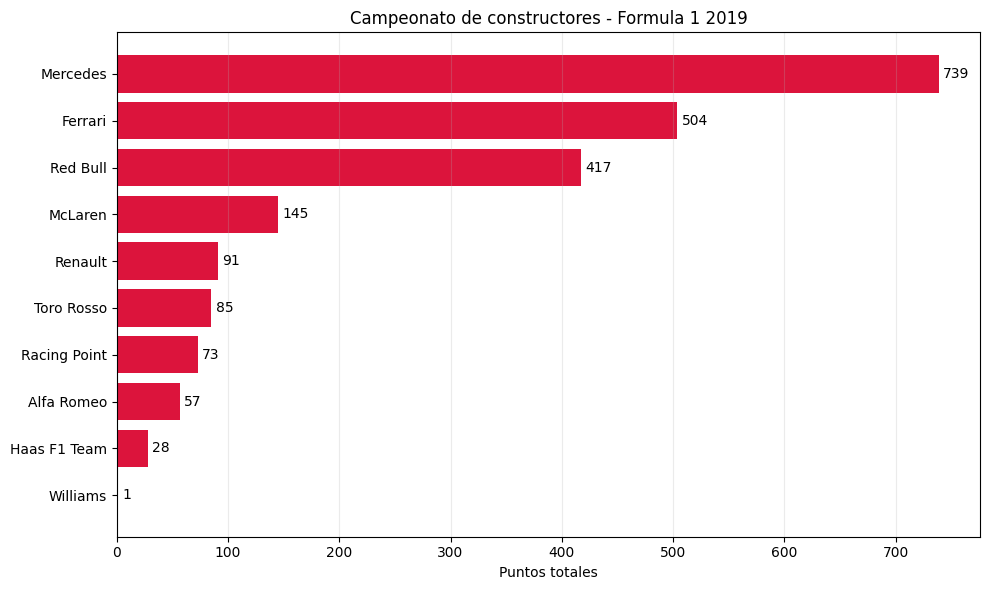

In [68]:
chart_data = constructor_performance_summary.sort_values(
    "puntos_totales",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    chart_data["constructor"],
    chart_data["puntos_totales"],
    color="crimson",
)

ax.bar_label(bars, padding=3, fmt="%.0f")
ax.set_xlabel("Puntos totales")
ax.set_title("Campeonato de constructores - Formula 1 2019")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [69]:
constructor_points_by_round = (
    analysis_clean
    .groupby(["round", "constructor"])["points"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

constructor_cumulative_points = constructor_points_by_round.cumsum()

constructor_cumulative_points.tail()

constructor,Alfa Romeo,Ferrari,Haas F1 Team,McLaren,Mercedes,Racing Point,Red Bull,Renault,Toro Rosso,Williams
round,,,,,,,,,,
17,35.0,435.0,28.0,111.0,612.0,58.0,323.0,68.0,62.0,1.0
18,35.0,466.0,28.0,111.0,652.0,64.0,341.0,73.0,64.0,1.0
19,35.0,479.0,28.0,121.0,695.0,65.0,366.0,83.0,64.0,1.0
20,57.0,479.0,28.0,140.0,701.0,67.0,391.0,91.0,83.0,1.0
21,57.0,504.0,28.0,145.0,739.0,73.0,417.0,91.0,85.0,1.0


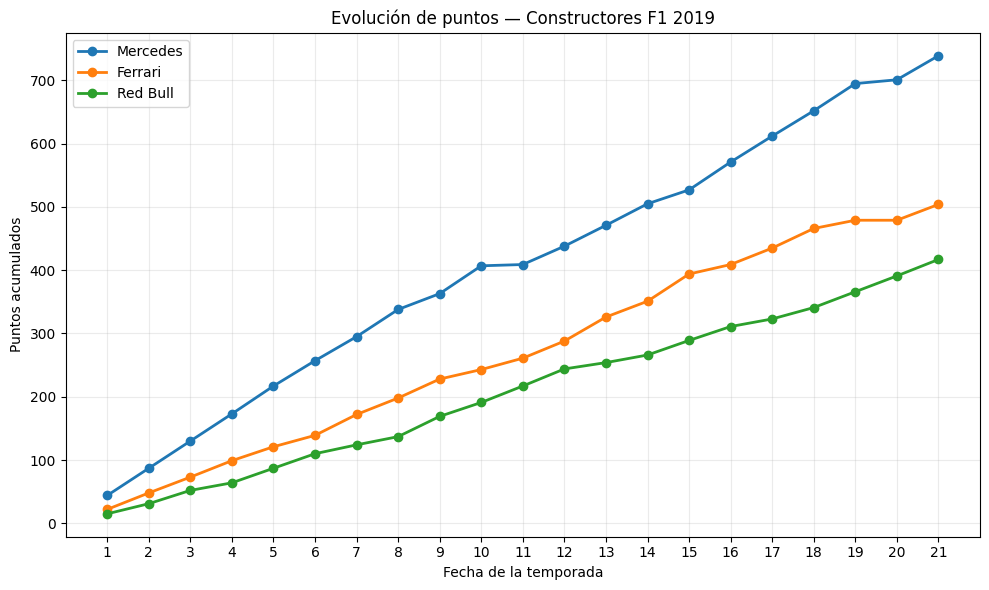

In [70]:
top_3_constructors = ["Mercedes", "Ferrari", "Red Bull"]

fig, ax = plt.subplots(figsize=(10, 6))

for constructor in top_3_constructors:
    ax.plot(
        constructor_cumulative_points.index,
        constructor_cumulative_points[constructor],
        marker="o",
        linewidth=2,
        label=constructor,
    )

ax.set_xlabel("Fecha de la temporada")
ax.set_ylabel("Puntos acumulados")
ax.set_title("Evolución de puntos — Constructores F1 2019")
ax.set_xticks(constructor_cumulative_points.index)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [71]:
title_battle = constructor_cumulative_points[
    ["Mercedes", "Ferrari"]
].copy()

title_battle["ventaja_mercedes"] = (
    title_battle["Mercedes"] - title_battle["Ferrari"]
)

title_battle.loc[[1, 21]]

constructor,Mercedes,Ferrari,ventaja_mercedes
round,,,
1,44.0,22.0,22.0
21,739.0,504.0,235.0


In [72]:
print("Ventaja mínima:", title_battle["ventaja_mercedes"].min())
print("Ventaja máxima:", title_battle["ventaja_mercedes"].max())
print(
    "Fecha de mayor ventaja:",
    title_battle["ventaja_mercedes"].idxmax(),
)

Ventaja mínima: 22.0
Ventaja máxima: 235.0
Fecha de mayor ventaja: 21


In [73]:
title_battle["cambio_ventaja"] = (
    title_battle["ventaja_mercedes"].diff()
)

reducciones_de_ventaja = title_battle.loc[
    title_battle["cambio_ventaja"] < 0
].copy()

reducciones_de_ventaja

constructor,Mercedes,Ferrari,ventaja_mercedes,cambio_ventaja
round,,,,
9,363.0,228.0,135.0,-5.0
11,409.0,261.0,148.0,-16.0
13,471.0,326.0,145.0,-5.0
15,527.0,394.0,133.0,-21.0


In [74]:
round_lookup = (
    analysis_clean[["round", "race_name"]]
    .drop_duplicates(subset="round")
)

reducciones_con_carrera = (
    reducciones_de_ventaja
    .reset_index()
    .merge(
        round_lookup,
        on="round",
        how="left",
        validate="many_to_one",
    )
    .sort_values("round")
)

reducciones_con_carrera[
    [
        "round",
        "race_name",
        "Mercedes",
        "Ferrari",
        "ventaja_mercedes",
        "cambio_ventaja",
    ]
]

,round,race_name,Mercedes,Ferrari,ventaja_mercedes,cambio_ventaja
0,9,Austrian Grand Prix,363.0,228.0,135.0,-5.0
1,11,German Grand Prix,409.0,261.0,148.0,-16.0
2,13,Belgian Grand Prix,471.0,326.0,145.0,-5.0
3,15,Singapore Grand Prix,527.0,394.0,133.0,-21.0


In [75]:
team_driver_points = (
    analysis_clean
    .groupby(["constructor", "driver"], as_index=False)
    .agg(
        puntos_totales=("points", "sum"),
    )
)

team_driver_points["puntos_equipo"] = (
    team_driver_points
    .groupby("constructor")["puntos_totales"]
    .transform("sum")
)

team_driver_points["porcentaje_del_equipo"] = (
    team_driver_points["puntos_totales"] / team_driver_points["puntos_equipo"] * 100
).round(1)

team_driver_points.sort_values(
    ["constructor", "puntos_totales"],
    ascending=[True, False],
)


,constructor,driver,puntos_totales,puntos_equipo,porcentaje_del_equipo
1,Alfa Romeo,Kimi Räikkönen,43.0,57.0,75.4
0,Alfa Romeo,Antonio Giovinazzi,14.0,57.0,24.6
2,Ferrari,Charles Leclerc,264.0,504.0,52.4
3,Ferrari,Sebastian Vettel,240.0,504.0,47.6
4,Haas F1 Team,Kevin Magnussen,20.0,28.0,71.4
5,Haas F1 Team,Romain Grosjean,8.0,28.0,28.6
6,McLaren,Carlos Sainz,96.0,145.0,66.2
7,McLaren,Lando Norris,49.0,145.0,33.8
8,Mercedes,Lewis Hamilton,413.0,739.0,55.9
9,Mercedes,Valtteri Bottas,326.0,739.0,44.1


In [76]:
race_position_summary = (
    analysis_clean
    .dropna(subset=["position_gained"])
    .groupby(
        ["round", "race_name", "circuit"],
        as_index=False,
    )
    .agg(
        comparaciones_validas=("position_gained", "count"),
        promedio_posiciones_ganadas=("position_gained", "mean"),
        total_posiciones_ganadas=("position_gained", "sum"),
    )
    .sort_values(
        "promedio_posiciones_ganadas",
        ascending=False,
    )
)

race_position_summary.head(10)

,round,race_name,circuit,comparaciones_validas,promedio_posiciones_ganadas,total_posiciones_ganadas
10,11,German Grand Prix,Hockenheimring,14,3.071429,43
1,2,Bahrain Grand Prix,Bahrain International Circuit,16,1.8125,29
13,14,Italian Grand Prix,Autodromo Nazionale di Monza,16,1.375,22
15,16,Russian Grand Prix,Sochi Autodrom,14,1.357143,19
0,1,Australian Grand Prix,Albert Park Grand Prix Circuit,17,1.235294,21
16,17,Japanese Grand Prix,Suzuka Circuit,16,1.125,18
17,18,Mexican Grand Prix,Autódromo Hermanos Rodríguez,18,0.944444,17
12,13,Belgian Grand Prix,Circuit de Spa-Francorchamps,17,0.941176,16
9,10,British Grand Prix,Silverstone Circuit,17,0.941176,16
3,4,Azerbaijan Grand Prix,Baku City Circuit,14,0.928571,13


In [77]:
germany_results = (
    analysis_clean.loc[
        analysis_clean["round"].eq(11),
        [
            "driver",
            "constructor",
            "grid",
            "finish_position",
            "position_gained",
            "points",
            "status",
        ],
    ]
    .sort_values(
        "position_gained",
        ascending=False,
        na_position="last",
    )
)

germany_results

,driver,constructor,grid,finish_position,position_gained,points,status
201,Sebastian Vettel,Ferrari,20,2,18,18.0,Finished
202,Daniil Kvyat,Toro Rosso,14,3,11,15.0,Finished
203,Lance Stroll,Racing Point,15,4,11,12.0,Finished
205,Alexander Albon,Toro Rosso,16,6,10,8.0,Finished
209,Robert Kubica,Williams,18,10,8,1.0,Finished
210,George Russell,Williams,17,11,6,0.0,Finished
207,Kevin Magnussen,Haas F1 Team,12,8,4,4.0,Finished
204,Carlos Sainz,McLaren,7,5,2,10.0,Finished
200,Max Verstappen,Red Bull,2,1,1,26.0,Finished
206,Romain Grosjean,Haas F1 Team,6,7,-1,6.0,Finished


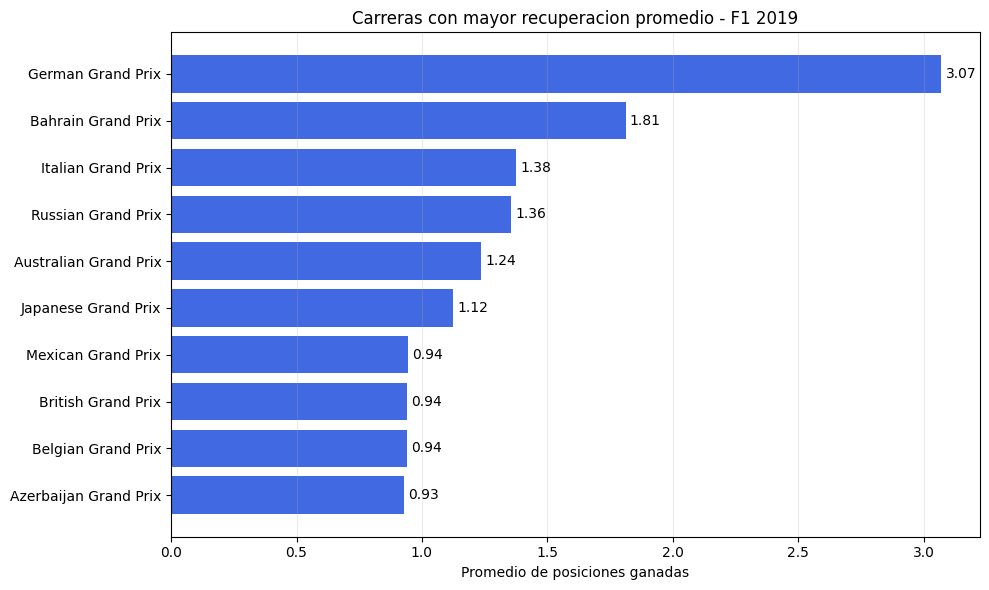

In [78]:
top_10_races = (
    race_position_summary
    .head(10)
    .sort_values(
        "promedio_posiciones_ganadas",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_10_races["race_name"],
    top_10_races["promedio_posiciones_ganadas"],
    color="royalblue",
)

ax.bar_label(bars, padding=3, fmt="%.2f")
ax.set_xlabel("Promedio de posiciones ganadas")
ax.set_title("Carreras con mayor recuperacion promedio - F1 2019")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Hallazgo: Recuperacion por carrera 

El Gran Premio de Alemania tuvo la mayor recuperacion promedio de posiciones de la temporada 2019 (3,07), claramente por encima de Bahréin (1,81). 
Sin embargo, los multiples incidentes y abandonos observados indican que se trató de una carrera atipica ; este resultado no alcanza para afirmar 
que Hockenheim sea, por sí solo, el circuito con mas adelantamientos.

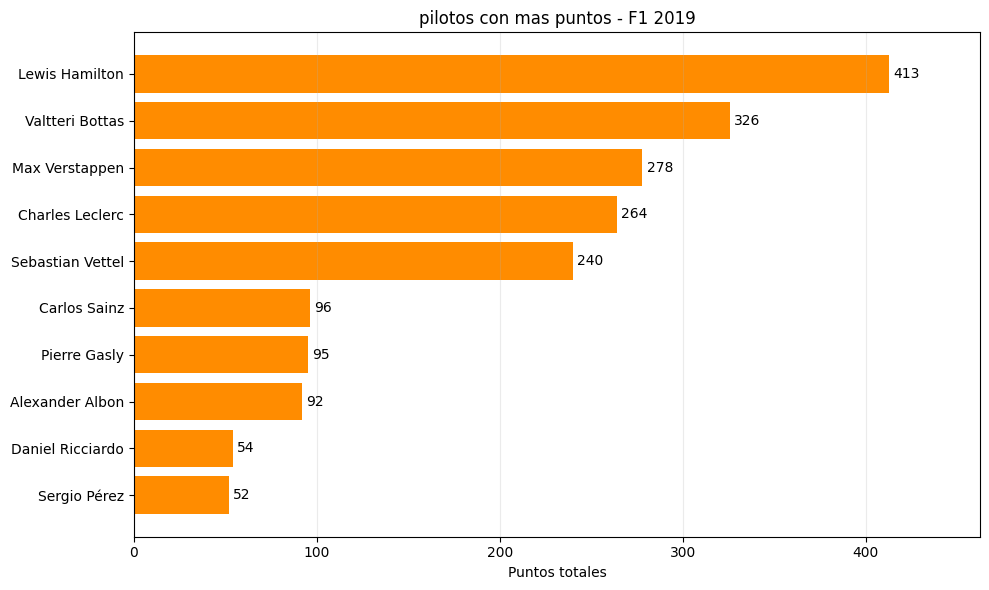

In [79]:
top_10_drivers = (
    driver_performance_summary
    .sort_values("puntos_totales", ascending=False)
    .head(10)
    .sort_values("puntos_totales")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_10_drivers["driver"],
    top_10_drivers["puntos_totales"],
    color="darkorange",
)

ax.bar_label(bars, padding=3, fmt="%.0f")
ax.set_xlim(0, top_10_drivers["puntos_totales"].max() * 1.12)
ax.set_xlabel("Puntos totales")
ax.set_title("pilotos con mas puntos - F1 2019")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Hallazgo: puntos y recuperación de posiciones

Observo que Hamilton lidera en puntos, mientras que Stroll encabeza la recuperación promedio de posiciones. Esta comparación muestra que recuperar más posiciones no implica necesariamente un mejor desempeño global: quienes largan más atrás tienen mayor margen para avanzar. La métrica representa el cambio neto entre largada y llegada, no la cantidad de adelantamientos en pista.

## Conclusiones de 2019

### Pilotos: puntos y recuperación de posiciones

Lance Stroll lideró la recuperación promedio, con 3,37 posiciones por carrera comparable, pero sumó 21 puntos. En contraste, Lewis Hamilton obtuvo 413 puntos, aunque su recuperación promedio fue ligeramente negativa. Esto muestra que recuperar más posiciones no implica necesariamente un mejor desempeño global. La posición de largada condiciona el margen disponible para avanzar: quienes largan más atrás tienen más posiciones que pueden ganar.

### Constructores: rendimiento y llegadas clasificadas

Mercedes lideró con 739 puntos, seguido por Ferrari con 504, una diferencia de 235 puntos. Williams, en cambio, registró un 90,5 % de llegadas clasificadas, pero sumó solo 1 punto. Esta comparación muestra que una alta proporción de llegadas clasificadas no garantiza resultados competitivos: también importa la posición obtenida.

### Carreras: el caso de Alemania y el límite de la métrica

El Gran Premio de Alemania tuvo la mayor recuperación promedio, con 3,07 posiciones, frente a 1,81 de Bahréin. Sin embargo, el cálculo de Alemania incluyó 14 resultados comparables y excluyó 6. Por eso, el promedio no representa a todos los participantes. Además, mido el cambio neto entre largada y llegada, no los adelantamientos en pista: las posiciones también pueden cambiar por abandonos, estrategias u otros factores.